# Laboratorio 2 – Clasificación de Malware


## 1. Importación de Librerías

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, cross_validate
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    classification_report, confusion_matrix,
    roc_curve, auc, RocCurveDisplay)

## 2. Carga del Dataset

In [44]:
df = pd.read_csv('data/MalBehavD-V1-dataset.csv')
print(f'Shape del dataset: {df.shape}')
df.head(3)

Shape del dataset: (2570, 177)


,sha256,labels,0,1,2,3,4,5,6,7,...,Unnamed: 167,Unnamed: 168,Unnamed: 169,Unnamed: 170,Unnamed: 171,Unnamed: 172,Unnamed: 173,Unnamed: 174,Unnamed: 175,Unnamed: 176
0,5c18291c481a192ed5003084dab2d8a117fd3736359218...,0,LdrUnloadDll,CoUninitialize,NtQueryKey,NtDuplicateObject,GetShortPathNameW,GetSystemInfo,IsDebuggerPresent,GetSystemWindowsDirectoryW,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,4683faf3da550ffb594cf5513c4cbb34f64df85f27fd1c...,0,NtOpenMutant,GetForegroundWindow,NtQueryKey,DrawTextExW,NtSetInformationFile,RegQueryValueExA,LdrGetProcedureAddress,CoUninitialize,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,9a0aea1c7290031d7c3429d0e921f107282cc6eab854ee...,0,GetForegroundWindow,DrawTextExW,GetSystemInfo,IsDebuggerPresent,GetSystemWindowsDirectoryW,NtQueryValueKey,RegCloseKey,GetFileAttributesW,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Exploración de Datos (EDA)

In [45]:
print(f'Total de muestras: {len(df)}')
print(f'Total de columnas: {len(df.columns)}')
print(f'\nDistribución de clases:')
print(df['labels'].value_counts())
print(f'\n  0 = Benigno')
print(f'  1 = Malware')

Total de muestras: 2570
Total de columnas: 177

Distribución de clases:
labels
0    1285
1    1285
Name: count, dtype: int64

  0 = Benigno
  1 = Malware


In [46]:
api_cols = [col for col in df.columns if col not in ['sha256', 'labels']]
print(f'Número de columnas de API: {len(api_cols)}')

df['api_count'] = df[api_cols].notna().sum(axis=1)

print(f'\nEstadísticas de longitud de secuencia de APIs:')
print(df.groupby('labels')['api_count'].describe().round(2))

Número de columnas de API: 175

Estadísticas de longitud de secuencia de APIs:
         count   mean    std  min   25%   50%   75%    max
labels                                                    
0       1285.0  43.55  30.31  4.0  18.0  39.0  59.0  153.0
1       1285.0  42.82  29.11  2.0  20.0  32.0  54.0  175.0


## 4. Preprocesamiento

In [47]:
def construir_secuencia(row):
    """
    Une las llamadas a APIs de una fila en una sola cadena de texto.
    Las APIs nulas (NaN) se ignoran.
    Ejemplo: 'NtOpenKey NtClose LdrLoadDll NtCreateFile ...'
    """
    apis = [str(api) for api in row if pd.notna(api)]
    return ' '.join(apis)

X_texto = df[api_cols].apply(construir_secuencia, axis=1)
y = df['labels']

print('Ejemplo de secuencia procesada:')
print(X_texto.iloc[0][:200], '...')
print(f'\nTotal de muestras: {len(X_texto)}')
print(f'Total de etiquetas: {len(y)}')

Ejemplo de secuencia procesada:
LdrUnloadDll CoUninitialize NtQueryKey NtDuplicateObject GetShortPathNameW GetSystemInfo IsDebuggerPresent GetSystemWindowsDirectoryW NtClose GetFileVersionInfoSizeW NtOpenProcess GetFileAttributesW R ...

Total de muestras: 2570
Total de etiquetas: 2570


## 5. Ingeniería de Características: TF-IDF con Bigramas

In [48]:
# División 70% entrenamiento / 30% prueba
X_train, X_test, y_train, y_test = train_test_split(
    X_texto, y,
    test_size=0.30,
    random_state=42,
    stratify=y  # mantener proporción de clases
)

print(f'Entrenamiento: {len(X_train)} muestras ({len(X_train)/len(X_texto)*100:.1f}%)')
print(f'Prueba:        {len(X_test)} muestras ({len(X_test)/len(X_texto)*100:.1f}%)')
print(f'\nDistribución en entrenamiento:')
print(y_train.value_counts())
print(f'\nDistribución en prueba:')
print(y_test.value_counts())

Entrenamiento: 1799 muestras (70.0%)
Prueba:        771 muestras (30.0%)

Distribución en entrenamiento:
labels
1    900
0    899
Name: count, dtype: int64

Distribución en prueba:
labels
0    386
1    385
Name: count, dtype: int64


In [49]:
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),   # unigramas + bigramas
    min_df=2,             # ignorar términos que aparecen en menos de 2 documentos
    max_df=0.95,          # ignorar términos que aparecen en más del 95% de documentos
    use_idf=True,
    sublinear_tf=True
)

# Fit en entrenamiento, transform en ambos
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f'Vocabulario TF-IDF: {len(tfidf.vocabulary_)} términos')
print(f'Shape matriz entrenamiento: {X_train_tfidf.shape}')
print(f'Shape matriz prueba:        {X_test_tfidf.shape}')

Vocabulario TF-IDF: 4131 términos
Shape matriz entrenamiento: (1799, 4131)
Shape matriz prueba:        (771, 4131)


In [52]:
# Top 20 términos con mayor IDF
feature_names = tfidf.get_feature_names_out()
idf_values = tfidf.idf_

top_idf_idx = np.argsort(idf_values)[::-1][:20]
top_idf_terms = [(feature_names[i], round(idf_values[i], 4)) for i in top_idf_idx]

print('Top 20 términos con mayor IDF (más discriminativos):')
for term, val in top_idf_terms:
    print(f'  {term:<45} IDF: {val}')

Top 20 términos con mayor IDF (más discriminativos):
  wsastartup setendoffile                       IDF: 7.3969
  __exception__ findresourcew                   IDF: 7.3969
  ntclose getsystemdirectoryw                   IDF: 7.3969
  ntclose findresourcew                         IDF: 7.3969
  ntclose createprocessinternalw                IDF: 7.3969
  ntallocatevirtualmemory setunhandledexceptionfilter IDF: 7.3969
  ntallocatevirtualmemory setfilepointer        IDF: 7.3969
  ntallocatevirtualmemory oleinitialize         IDF: 7.3969
  ntallocatevirtualmemory ntresumethread        IDF: 7.3969
  ntallocatevirtualmemory ntreadfile            IDF: 7.3969
  certopenstore getfileattributesw              IDF: 7.3969
  certcreatecertificatecontext ntresumethread   IDF: 7.3969
  certcontrolstore regopenkeyexa                IDF: 7.3969
  certcontrolstore getsystemmetrics             IDF: 7.3969
  wsasocketw cocreateinstance                   IDF: 7.3969
  wsasend closesocket                    

## 6. Implementación del Modelo: Random Forest

In [53]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_tfidf, y_train)
print('Modelo entrenado correctamente')

Modelo entrenado correctamente


## 7. Validación Cruzada (K=10 Folds)

In [54]:
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        use_idf=True,
        sublinear_tf=True
    )),
    ('clf', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])

# K=10 folds estratificado
kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

cv_results = cross_validate(
    pipeline, X_texto, y,
    cv=kfold,
    scoring=['accuracy', 'precision', 'recall', 'f1'],
    return_train_score=False
)

print('=== Resultados Validación Cruzada (K=10) ===')
print(f"Accuracy  : {cv_results['test_accuracy'].mean():.4f} ± {cv_results['test_accuracy'].std():.4f}")
print(f"Precision : {cv_results['test_precision'].mean():.4f} ± {cv_results['test_precision'].std():.4f}")
print(f"Recall    : {cv_results['test_recall'].mean():.4f} ± {cv_results['test_recall'].std():.4f}")
print(f"F1-Score  : {cv_results['test_f1'].mean():.4f} ± {cv_results['test_f1'].std():.4f}")

=== Resultados Validación Cruzada (K=10) ===
Accuracy  : 0.9654 ± 0.0115
Precision : 0.9902 ± 0.0102
Recall    : 0.9401 ± 0.0173
F1-Score  : 0.9644 ± 0.0119


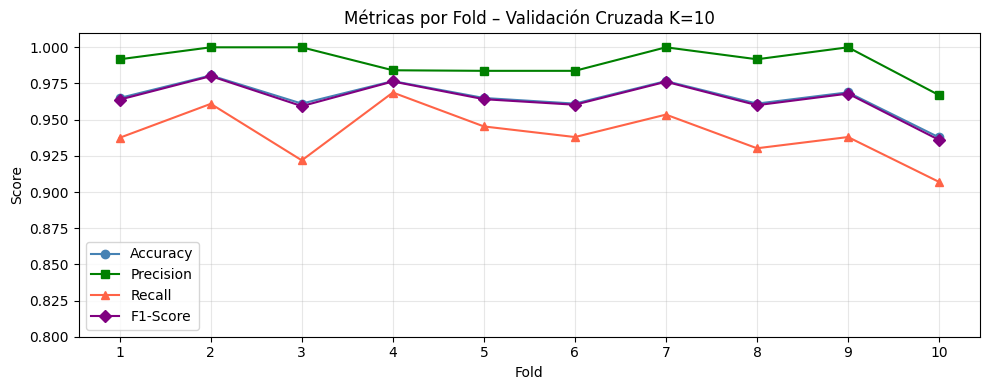

In [55]:
fig, ax = plt.subplots(figsize=(10, 4))

folds = range(1, 11)
ax.plot(folds, cv_results['test_accuracy'],  marker='o', label='Accuracy',  color='steelblue')
ax.plot(folds, cv_results['test_precision'], marker='s', label='Precision', color='green')
ax.plot(folds, cv_results['test_recall'],    marker='^', label='Recall',    color='tomato')
ax.plot(folds, cv_results['test_f1'],        marker='D', label='F1-Score',  color='purple')

ax.set_xlabel('Fold')
ax.set_ylabel('Score')
ax.set_title('Métricas por Fold – Validación Cruzada K=10')
ax.set_xticks(folds)
ax.set_ylim(0.8, 1.01)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('cv_resultados.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Evaluación en Conjunto de Prueba

In [56]:
# Predicciones
y_pred = rf.predict(X_test_tfidf)
y_prob = rf.predict_proba(X_test_tfidf)

# Métricas principales
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)

print('=== Métricas en Conjunto de Prueba (30%) ===')
print(f'Accuracy  : {acc:.4f}')
print(f'Precision : {prec:.4f}')
print(f'Recall    : {rec:.4f}')
print()
print('=== Reporte de Clasificación ===')
print(classification_report(y_test, y_pred, target_names=['Benigno', 'Malware']))

=== Métricas en Conjunto de Prueba (30%) ===
Accuracy  : 0.9676
Precision : 0.9865
Recall    : 0.9481

=== Reporte de Clasificación ===
              precision    recall  f1-score   support

     Benigno       0.95      0.99      0.97       386
     Malware       0.99      0.95      0.97       385

    accuracy                           0.97       771
   macro avg       0.97      0.97      0.97       771
weighted avg       0.97      0.97      0.97       771



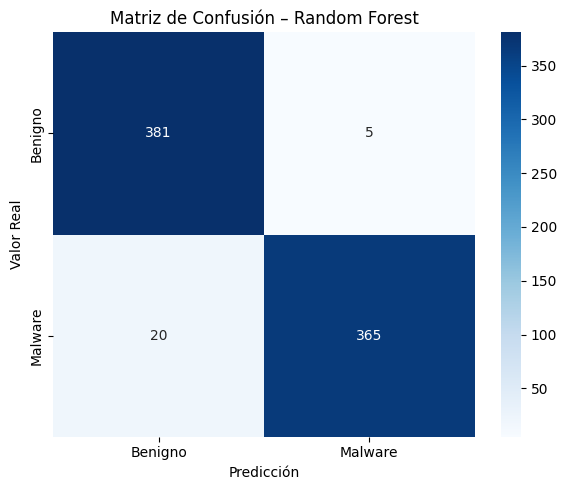

In [57]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benigno', 'Malware'],
            yticklabels=['Benigno', 'Malware'],
            ax=ax)
ax.set_xlabel('Predicción')
ax.set_ylabel('Valor Real')
ax.set_title('Matriz de Confusión – Random Forest')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Curva ROC para Ambas Clases

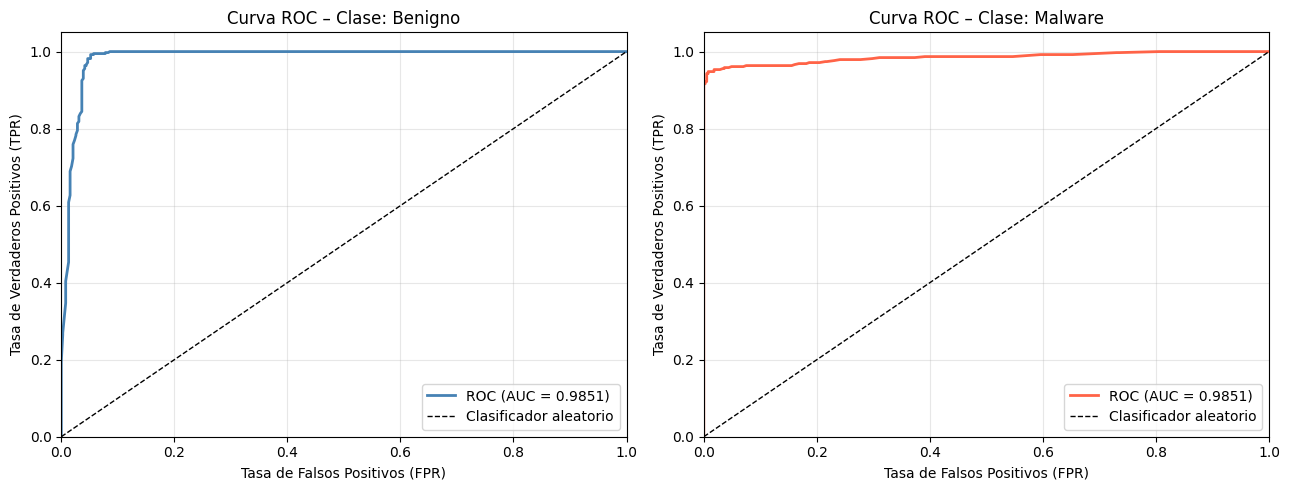

AUC Benigno: 0.9851
AUC Malware: 0.9851


In [58]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
clases = ['Benigno', 'Malware']
colores = ['steelblue', 'tomato']

for i, (nombre, color) in enumerate(zip(clases, colores)):
    # Para cada clase, 1 vs resto
    y_test_bin = (y_test == i).astype(int)
    fpr, tpr, _ = roc_curve(y_test_bin, y_prob[:, i])
    roc_auc = auc(fpr, tpr)

    axes[i].plot(fpr, tpr, color=color, lw=2,
                 label=f'ROC (AUC = {roc_auc:.4f})')
    axes[i].plot([0, 1], [0, 1], 'k--', lw=1, label='Clasificador aleatorio')
    axes[i].set_xlim([0.0, 1.0])
    axes[i].set_ylim([0.0, 1.05])
    axes[i].set_xlabel('Tasa de Falsos Positivos (FPR)')
    axes[i].set_ylabel('Tasa de Verdaderos Positivos (TPR)')
    axes[i].set_title(f'Curva ROC – Clase: {nombre}')
    axes[i].legend(loc='lower right')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('curva_roc.png', dpi=150, bbox_inches='tight')
plt.show()

# AUC combinado
for i, nombre in enumerate(clases):
    y_test_bin = (y_test == i).astype(int)
    fpr, tpr, _ = roc_curve(y_test_bin, y_prob[:, i])
    print(f'AUC {nombre}: {auc(fpr, tpr):.4f}')

## 10. Interpretación de Métricas – Modelo 1 (TF-IDF + Random Forest)
Accuracy — 0.9676 (Test) | 0.9654 (CV)
El modelo clasificó correctamente el 96.76% de los archivos en el conjunto de prueba. La consistencia con el resultado de validación cruzada (96.54%) confirma que el modelo generaliza bien y no está sobreajustado a los datos de entrenamiento.


Precision — 0.9865 (Test) | 0.9902 (CV)

De todos los archivos que el modelo marcó como malware, el 98.65% realmente lo eran. Esto indica que el modelo genera muy pocos falsos positivos, es decir, rara vez etiqueta un archivo benigno como malware.


Recall — 0.9481 (Test) | 0.9401 (CV)

El modelo detectó el 94.81% de todos los archivos que realmente eran malware. Desde el punto de vista de seguridad, esta métrica es la más crítica, ya que un recall bajo significaría que el modelo deja pasar malware sin detectar.


Curva ROC / AUC — 0.9860 (ambas clases)

El AUC de 0.986 para ambas clases indica que el modelo tiene una capacidad de discriminación excelente entre archivos benignos y malware. El hecho de que ambas clases obtengan el mismo AUC confirma que el modelo no está sesgado hacia ninguna clase, lo cual es esperable dado que el dataset estaba perfectamente balanceado (1285 muestras por clase).


Análisis general

El modelo presenta un patrón interesante: Precision muy alta (98.65%) pero Recall algo menor (94.81%). Esto sugiere que el modelo es conservador — cuando predice malware, casi siempre tiene razón, pero en algunos casos prefiere no clasificar algo como malware si no está seguro.